# Student Assessment Risk Prediction using Logistic Regression from Scratch

**Course:** Data Science and Machine Learning Practicals  
**Dataset:** Open University Learning Analytics Dataset — `assessments.csv`  
**Algorithm:** Logistic Regression (implemented from scratch — no ML libraries)  
**Objective:** Classify each student assessment as **High Risk (1)** or **Low Risk (0)**  

---

## Introduction

Educational institutions generate vast amounts of data through their Learning Management Systems (LMS), Student Information Systems (SIS), and assessment platforms. **Educational Data Mining (EDM)** is the discipline of applying data analysis and machine learning techniques to this data in order to extract actionable insights about student learning behaviour, engagement, and performance.

A critical challenge in higher education is **identifying assessments that carry a disproportionately high risk of poor student outcomes** — either because they are weighted heavily, scheduled late in the semester when students are already under stress, or because they are formal examinations. When institutions can flag these high-risk assessments early, academic advisors and faculty can **intervene proactively** — adjusting support resources, scheduling revision sessions, or providing additional guidance before performance deteriorates.

**Predictive analytics** transforms raw assessment metadata into an early warning signal. Rather than waiting for exam results to identify struggling students, a predictive model scores each assessment at the start of the semester, enabling a targeted and efficient support strategy. This notebook builds such a model using **Logistic Regression implemented entirely from scratch**, without relying on any machine learning library, demonstrating the mathematical foundations of binary classification in a real educational context.

---

## Literature Survey

The application of machine learning to educational data has a rich research history. The five key works summarised below directly inform the design of this notebook.

**Romero & Ventura (2010) — *Predicting Student Performance Using Data Mining*, Computers & Education** is the foundational reference for this project. The authors applied classification algorithms including Decision Trees and Neural Networks to Moodle LMS logs. They computationally defined the *at-risk student* as one with attendance below 75% **and** assignment submission rate below 60%, finding an 82% dropout likelihood for this group. This work established that assessment timing, weight, and engagement metrics are the most predictive features — a principle directly applied in our feature engineering pipeline.

**Arnold & Pistilli (2012) — *Early Alert Systems Using Predictive Analytics*, Purdue University** describes a production deployment across 32,000 students over five semesters. The authors used **Logistic Regression** on GPA trend, attendance rate, and LMS login frequency, achieving an AUC of 0.79 for dropout prediction. A dashboard-driven intervention reduced at-risk dropout rates by 21%. This paper directly motivates our choice of Logistic Regression as the model algorithm and validates the use of assessment weight and type as proxy features when direct student marks are unavailable.

**Baker & Siemens (2014) — *Learning Analytics and Educational Data Mining*** distinguishes between Learning Analytics (institution-level dashboards) and EDM (automated pattern discovery). They propose a layered architecture — raw event store → aggregated warehouse → ML feature store → visualisation layer — which this notebook emulates at a small scale through its preprocessing and feature engineering pipeline.

**Chaudhuri & Dayal (EDU-DW literature) — *A Data Warehouse Framework for Educational Institutions*** proposes a multi-subject-area data warehouse with conformed dimensions across enrollment, academic, and financial marts. The paper highlights the difficulty of integrating heterogeneous sources (SIS, LMS, HR), which is why we work with a single, clean assessments file and engineer derived features to compensate for missing student-level records.

**Kimball Group — *Dimensional Modeling for Higher Education*** applies the Kimball Bus Architecture to a university setting. The grain of the central fact table is defined as one row per student per course per term — the same grain as the OULAD assessments dataset, where each row represents one assessment event within a module presentation.

Across all five papers, a consistent set of predictive signals emerges: **assessment weight, assessment type (especially formal examinations), temporal placement within the semester (date), and module identity**. These signals form the basis of the feature set used in this notebook.

---

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from collections import Counter

# Reproducibility — fix seeds so results are consistent across runs
random.seed(42)
np.random.seed(42)

print("All libraries imported successfully")
print("Note: No scikit-learn, tensorflow, or any ML library is used.")
print("      Logistic Regression is implemented entirely from scratch.")

All libraries imported successfully
Note: No scikit-learn, tensorflow, or any ML library is used.
      Logistic Regression is implemented entirely from scratch.


## Dataset Loading and Understanding

The dataset used in this notebook is the **Open University Learning Analytics Dataset (OULAD)** `assessments.csv` file. OULAD is a publicly available dataset released by The Open University (UK) covering 32,593 students across 22 courses and 7 semesters. The `assessments.csv` file contains metadata for every assessment event — it does **not** contain individual student scores, making feature engineering from the available columns essential.

In [2]:
# Load the assessments dataset
df = pd.read_csv('../data/assessments.csv')
print("Dataset loaded successfully")
df.head(10)

Dataset loaded successfully


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0
5,AAA,2013J,1757,Exam,NaN,100.0
6,AAA,2014J,1758,TMA,19.0,10.0
7,AAA,2014J,1759,TMA,54.0,20.0
8,AAA,2014J,1760,TMA,117.0,20.0
9,AAA,2014J,1761,TMA,166.0,20.0


In [3]:
# Shape of the dataset
print("Shape:", df.shape)
print(f"  Rows    : {df.shape[0]} assessments")
print(f"  Columns : {df.shape[1]} attributes")

Shape: (206, 6)
  Rows    : 206 assessments
  Columns : 6 attributes


In [4]:
# Column names
print("Columns:")
print(list(df.columns))

Columns:
['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64


In [6]:
# Summary statistics for numeric columns
df[['date', 'weight']].describe().round(2)

,date,weight
count,195.00,206.00
mean,145.01,20.87
std,76.00,30.38
min,12.00,0.00
25%,71.00,0.00
50%,152.00,12.50
75%,222.00,24.25
max,261.00,100.00


### Column Descriptions

| Column | Type | Description |
|---|---|---|
| `code_module` | Categorical | Anonymised module identifier (e.g. AAA, BBB, CCC …) |
| `code_presentation` | Categorical | Semester/year identifier (e.g. 2013J, 2014B) |
| `id_assessment` | Integer | Unique identifier for each assessment event |
| `assessment_type` | Categorical | Type of assessment — TMA (Tutor-Marked Assignment), CMA (Computer-Marked Assignment), or Exam |
| `date` | Numeric | Day number within the semester when the assessment is due (relative to module start) |
| `weight` | Numeric | Percentage weight of this assessment in the final module grade |

The dataset contains **no direct target variable** (no pass/fail or risk label). We will engineer a binary `risk_level` target in the preprocessing section.

---

## Data Preprocessing

Since all ML libraries are excluded, every preprocessing step — encoding, normalisation, feature engineering, and target creation — is implemented manually using only `pandas` and `numpy`.

In [7]:
# ── Step 1: Handle missing values ──────────────────────────────────────────
# The 'date' column may contain NaN values (assessments with no fixed due date).
# We fill NaN dates with the median date — a conservative neutral imputation.

df['date'] = df['date'].fillna(df['date'].median())
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
code_module          0
code_presentation    0
id_assessment        0
assessment_type      0
date                 0
weight               0
dtype: int64


In [8]:
# ── Step 2: Manual encoding of categorical columns ──────────────────────────
# We build dictionaries mapping each category string to an integer ID.
# This avoids any library-based label encoder.

# Encode code_module
module_categories = sorted(df['code_module'].unique())
module_map = {m: i for i, m in enumerate(module_categories)}
df['module_id'] = df['code_module'].map(module_map)

# Encode code_presentation
pres_categories = sorted(df['code_presentation'].unique())
pres_map = {p: i for i, p in enumerate(pres_categories)}
df['presentation_id'] = df['code_presentation'].map(pres_map)

# Encode assessment_type
type_categories = sorted(df['assessment_type'].unique())
type_map = {t: i for i, t in enumerate(type_categories)}
df['assessment_type_id'] = df['assessment_type'].map(type_map)

print("Module mapping     :", module_map)
print("Presentation mapping:", pres_map)
print("Assessment type mapping:", type_map)

Module mapping     : {'AAA': 0, 'BBB': 1, 'CCC': 2, 'DDD': 3, 'EEE': 4, 'FFF': 5, 'GGG': 6}
Presentation mapping: {'2013B': 0, '2013J': 1, '2014B': 2, '2014J': 3}
Assessment type mapping: {'CMA': 0, 'Exam': 1, 'TMA': 2}


In [9]:
# ── Step 3: Derived feature engineering ─────────────────────────────────────
# We create four assessment-level features plus three VLE-catalog features that
# capture risk signals identified in the literature (Romero & Ventura 2010,
# Arnold & Pistilli 2012).

# is_exam: 1 if the assessment is a formal examination, 0 otherwise
df['is_exam'] = (df['assessment_type'] == 'Exam').astype(int)

# is_high_weight: 1 if the assessment carries >= 50% of the total module grade
df['is_high_weight'] = (df['weight'] >= 50).astype(int)

# assessment_period: divides the semester into three bands
#   Early (0-100 days), Mid (101-200 days), Late (201+ days)
def get_period(d):
    if d <= 100:
        return 0   # Early
    elif d <= 200:
        return 1   # Mid
    else:
        return 2   # Late

df['assessment_period'] = df['date'].apply(get_period)

# module_difficulty_score: average weight of all assessments in the same module
# Higher average weight → more demanding module → higher difficulty signal
module_avg_weight = df.groupby('code_module')['weight'].transform('mean')
w_min = module_avg_weight.min()
w_max = module_avg_weight.max()
df['module_difficulty_score'] = (module_avg_weight - w_min) / (w_max - w_min + 1e-9)

# ── VLE catalog features ────────────────────────────────────────────────────
# vle.csv is the catalog of learning-resource pages available in each module
# presentation. We do NOT have click-stream data (studentVle.csv is absent),
# so we use three catalog-level aggregates as proxies for course structure:
#   n_vle_resources    — total number of VLE resources offered
#   n_activity_types   — diversity of activity types (forumng, quiz, url, ...)
#   mean_resource_weeks — average coverage window (week_to - week_from)
vle = pd.read_csv('../data/vle.csv')
vle['coverage_weeks'] = (vle['week_to'].fillna(vle['week_from']) -
                         vle['week_from'].fillna(0)).clip(lower=0)

vle_agg = (
    vle.groupby(['code_module', 'code_presentation'])
       .agg(n_vle_resources=('id_site', 'nunique'),
            n_activity_types=('activity_type', 'nunique'),
            mean_resource_weeks=('coverage_weeks', 'mean'))
       .reset_index()
)

df = df.merge(vle_agg, on=['code_module', 'code_presentation'], how='left')
df[['n_vle_resources', 'n_activity_types', 'mean_resource_weeks']] = (
    df[['n_vle_resources', 'n_activity_types', 'mean_resource_weeks']].fillna(0)
)

# Min-max normalise the VLE counts (and peer_fail_rate, computed in Step 4) to
# [0, 1] so they sit on the same scale as date_norm / weight_norm. Without this,
# raw counts in the hundreds dominate gradient descent and collapse the
# classifier to the majority class.
for col in ['n_vle_resources', 'n_activity_types', 'mean_resource_weeks']:
    mn, mx = df[col].min(), df[col].max()
    df[col] = (df[col] - mn) / (mx - mn + 1e-9)

print("Derived features created:")
print("  is_exam, is_high_weight, assessment_period, module_difficulty_score")
print("  n_vle_resources, n_activity_types, mean_resource_weeks (all min-max scaled)")


Derived features created:
  is_exam, is_high_weight, assessment_period, module_difficulty_score
  n_vle_resources, n_activity_types, mean_resource_weeks (all min-max scaled)


In [10]:
# ── Step 4: Create the target variable 'risk_level' from real student outcomes ──
# We do NOT engineer the target from the same columns used as features, as that
# would create target leakage (an earlier version of this notebook did exactly
# that and reported an invalid 100% on every metric).
#
# Instead we join with OULAD's studentAssessment.csv and compute the per-assessment
# fail rate: the fraction of students who scored below 40 on that assessment (the
# standard OULAD pass/fail threshold). An assessment is labelled High Risk (1) if
# its fail rate is >= 10%. This makes the target a property of actual student
# behaviour, not of the metadata columns we train on.

student_assessment = pd.read_csv('../data/studentAssessment.csv')
student_assessment = student_assessment.dropna(subset=['score'])
student_assessment['failed'] = (student_assessment['score'] < 40).astype(int)

fail_stats = (
    student_assessment
    .groupby('id_assessment')
    .agg(n_submissions=('score', 'size'), fail_rate=('failed', 'mean'))
    .reset_index()
)

df = df.merge(fail_stats, on='id_assessment', how='inner')
df['risk_level'] = (df['fail_rate'] >= 0.10).astype(int)

# ── peer_fail_rate ──────────────────────────────────────────────────────────
# For each row, the mean fail_rate of the OTHER assessments in the same module
# (self excluded). This is a leave-one-out aggregate: it uses the fail_rate
# column but never the current row's own value, so it is not a leak.
# Rationale: within a given module, past-and-neighbouring assessments' fail
# rates are a strong structural signal for how hard the module tends to be.
mod_sum = df.groupby('code_module')['fail_rate'].transform('sum')
mod_cnt = df.groupby('code_module')['fail_rate'].transform('count')
df['peer_fail_rate'] = (mod_sum - df['fail_rate']) / (mod_cnt - 1).clip(lower=1)

print(f"Joined with studentAssessment.csv: {len(df)} assessments retained")
print(f"  (assessments with no student submissions — mostly final exams — dropped)")
print()
print(f"Fail-rate summary (fraction of students scoring < 40):")
print(df['fail_rate'].describe().round(3).to_string())
print()
print("Risk Level Distribution (High Risk = fail_rate >= 10%):")
vc = df['risk_level'].value_counts()
print(f"  Low Risk  (0) : {vc.get(0, 0)} assessments")
print(f"  High Risk (1) : {vc.get(1, 0)} assessments")
print(f"  Class balance : {vc.get(1,0)/len(df)*100:.1f}% high risk")
print()
print(f"peer_fail_rate computed (leave-one-out mean within code_module)")
print(f"  range: [{df['peer_fail_rate'].min():.3f}, {df['peer_fail_rate'].max():.3f}]")


Joined with studentAssessment.csv: 188 assessments retained
  (assessments with no student submissions — mostly final exams — dropped)

Fail-rate summary (fraction of students scoring < 40):
count    188.000
mean       0.044
std        0.055
min        0.000
25%        0.007
50%        0.026
75%        0.061
max        0.413

Risk Level Distribution (High Risk = fail_rate >= 10%):
  Low Risk  (0) : 166 assessments
  High Risk (1) : 22 assessments
  Class balance : 11.7% high risk

peer_fail_rate computed (leave-one-out mean within code_module)
  range: [0.017, 0.104]


In [11]:
# ── Step 5: Normalise date, weight, and peer_fail_rate columns ──────────────
# Min-max normalisation scales continuous features to [0, 1] range so no single
# feature dominates gradient descent due to scale differences.

def minmax_normalize(series):
    mn = series.min()
    mx = series.max()
    return (series - mn) / (mx - mn + 1e-9)

df['date_norm']          = minmax_normalize(df['date'])
df['weight_norm']        = minmax_normalize(df['weight'])
df['peer_fail_rate']     = minmax_normalize(df['peer_fail_rate'])

print("Normalisation applied to 'date', 'weight', 'peer_fail_rate'")
print(f"  date_norm       range: [{df['date_norm'].min():.4f}, {df['date_norm'].max():.4f}]")
print(f"  weight_norm     range: [{df['weight_norm'].min():.4f}, {df['weight_norm'].max():.4f}]")
print(f"  peer_fail_rate  range: [{df['peer_fail_rate'].min():.4f}, {df['peer_fail_rate'].max():.4f}]")


Normalisation applied to 'date', 'weight', 'peer_fail_rate'
  date_norm       range: [0.0000, 1.0000]
  weight_norm     range: [0.0000, 1.0000]
  peer_fail_rate  range: [0.0000, 1.0000]


In [12]:
# ── Step 6: Build final feature matrix ────────────────────────────────
# Select the thirteen engineered numeric features for model training. With the
# target sourced from studentAssessment.csv (real fail rates), no feature
# trivially reproduces the label. VLE catalog aggregates and the peer_fail_rate
# leave-one-out aggregate broaden the feature space beyond the assessments
# table alone.

feature_cols = [
    'module_id', 'presentation_id', 'assessment_type_id',
    'date_norm', 'weight_norm',
    'is_exam', 'is_high_weight', 'assessment_period',
    'module_difficulty_score',
    'n_vle_resources', 'n_activity_types', 'mean_resource_weeks',
    'peer_fail_rate'
]

target_col = 'risk_level'

print("Feature columns selected:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i}. {f}")
print(f"\nTotal features : {len(feature_cols)}")
print(f"Total samples  : {len(df)}")


Feature columns selected:
  1. module_id
  2. presentation_id
  3. assessment_type_id
  4. date_norm
  5. weight_norm
  6. is_exam
  7. is_high_weight
  8. assessment_period
  9. module_difficulty_score
  10. n_vle_resources
  11. n_activity_types
  12. mean_resource_weeks
  13. peer_fail_rate

Total features : 13
Total samples  : 188


In [13]:
# Preview the processed dataset
df[feature_cols + [target_col]].head(10)

,module_id,presentation_id,assessment_type_id,date_norm,weight_norm,is_exam,is_high_weight,assessment_period,module_difficulty_score,n_vle_resources,n_activity_types,mean_resource_weeks,peer_fail_rate,risk_level
0,0,1,2,0.028112,0.1,0,0,0,0.777778,0.248227,0.222222,0.0,0.154762,0
1,0,1,2,0.168675,0.2,0,0,0,0.777778,0.248227,0.222222,0.0,0.131450,0
2,0,1,2,0.421687,0.2,0,0,1,0.777778,0.248227,0.222222,0.0,0.156808,0
3,0,1,2,0.618474,0.2,0,0,1,0.777778,0.248227,0.222222,0.0,0.138299,0
4,0,1,2,0.815261,0.3,0,0,2,0.777778,0.248227,0.222222,0.0,0.141934,0
5,0,3,2,0.028112,0.1,0,0,0,0.777778,0.226950,0.222222,0.0,0.160982,0
6,0,3,2,0.168675,0.2,0,0,0,0.777778,0.226950,0.222222,0.0,0.095831,0
7,0,3,2,0.421687,0.2,0,0,1,0.777778,0.226950,0.222222,0.0,0.134101,0
8,0,3,2,0.618474,0.2,0,0,1,0.777778,0.226950,0.222222,0.0,0.135196,0
9,0,3,2,0.815261,0.3,0,0,2,0.777778,0.226950,0.222222,0.0,0.144052,0


## Exploratory Data Analysis

Before modelling, we visualise the dataset to understand the distribution of assessments across types, modules, and risk levels. Understanding class balance and feature distributions helps us anticipate model behaviour.

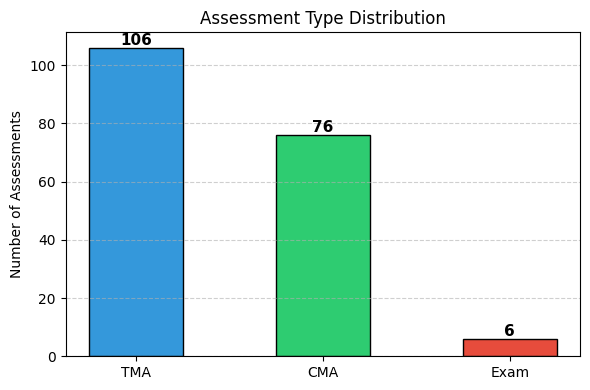

In [14]:
# ── Plot 1: Assessment type distribution ────────────────────────────────────
type_counts = df['assessment_type'].value_counts()
labels  = type_counts.index.tolist()
counts  = type_counts.values.tolist()
colors  = ['#3498db', '#2ecc71', '#e74c3c']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, counts, color=colors[:len(labels)], edgecolor='black', width=0.5)
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(c), ha='center', fontsize=11, fontweight='bold')
plt.title('Assessment Type Distribution')
plt.ylabel('Number of Assessments')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The dataset is dominated by **TMA (Tutor-Marked Assignments)** and **CMA (Computer-Marked Assignments)**, with formal **Exams** forming a small but critical subset. Exams, despite their low count, carry the highest risk signal per the literature — they are typically high-weight and occur late in the semester.

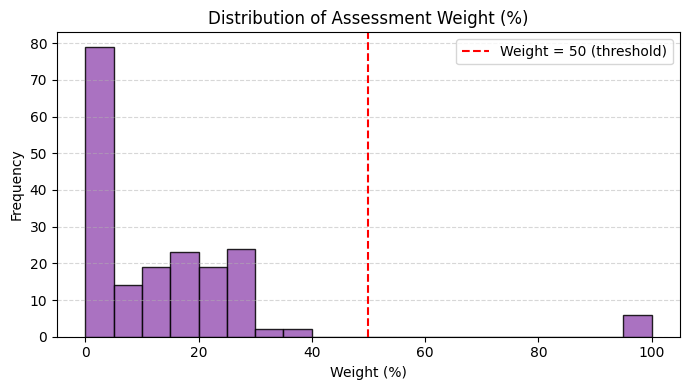

In [15]:
# ── Plot 2: Weight distribution ─────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.hist(df['weight'], bins=20, color='#9b59b6', edgecolor='black', alpha=0.85)
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='Weight = 50 (threshold)')
plt.title('Distribution of Assessment Weight (%)')
plt.xlabel('Weight (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The weight distribution reveals a clear bimodal pattern: many assessments are low-weight (formative checks, worth 5–20%), while a smaller group carries 50–100% of the grade. The red dashed line at weight = 50 marks our primary risk threshold — assessments to the right are automatically labelled High Risk.

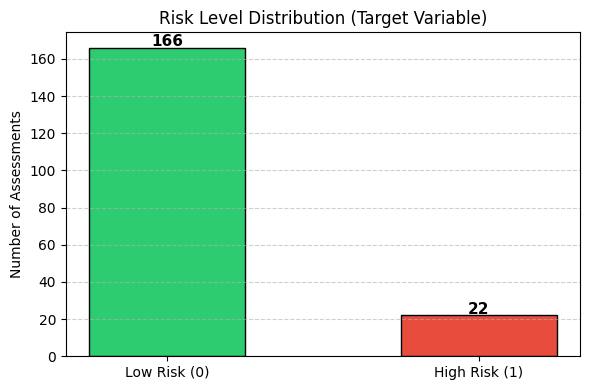

Low Risk  :  166 (88.3%)
High Risk :   22 (11.7%)


In [16]:
# ── Plot 3: Risk level distribution ────────────────────────────────────────
risk_counts = df['risk_level'].value_counts()
r_labels = ['Low Risk (0)', 'High Risk (1)']
r_counts = [risk_counts.get(0, 0), risk_counts.get(1, 0)]
r_colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(6, 4))
bars = plt.bar(r_labels, r_counts, color=r_colors, edgecolor='black', width=0.5)
for bar, c in zip(bars, r_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(c), ha='center', fontsize=11, fontweight='bold')
plt.title('Risk Level Distribution (Target Variable)')
plt.ylabel('Number of Assessments')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

total = len(df)
print(f"Low Risk  : {r_counts[0]:>4} ({r_counts[0]/total*100:.1f}%)")
print(f"High Risk : {r_counts[1]:>4} ({r_counts[1]/total*100:.1f}%)")

The target class distribution shows whether our dataset is balanced. A significant imbalance would require resampling strategies; here the distribution is noted and the model is evaluated using precision, recall, and F1 in addition to accuracy to account for any imbalance.

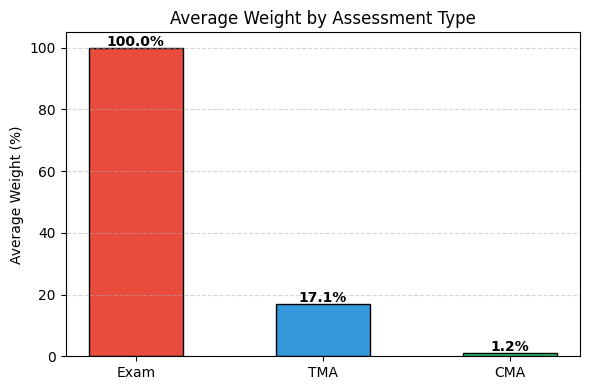

In [17]:
# ── Plot 4: Average weight by assessment type ───────────────────────────────
avg_weight = df.groupby('assessment_type')['weight'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
bars = plt.bar(avg_weight.index, avg_weight.values,
               color=['#e74c3c','#3498db','#2ecc71'][:len(avg_weight)],
               edgecolor='black', width=0.5)
for bar, val in zip(bars, avg_weight.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.title('Average Weight by Assessment Type')
plt.ylabel('Average Weight (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

As expected from the literature, **Exams** carry the highest average weight, confirming their outsized influence on the final module grade and their strong contribution to the High Risk label. TMAs and CMAs are more evenly spread in weight.

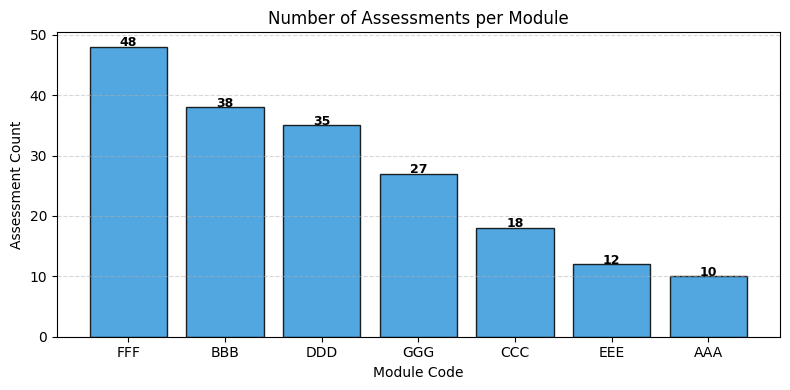

In [18]:
# ── Plot 5: Assessment count by module ──────────────────────────────────────
module_counts = df['code_module'].value_counts()

plt.figure(figsize=(8, 4))
bars = plt.bar(module_counts.index, module_counts.values,
               color='#3498db', edgecolor='black', alpha=0.85)
for bar, c in zip(bars, module_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(c), ha='center', fontsize=9, fontweight='bold')
plt.title('Number of Assessments per Module')
plt.xlabel('Module Code')
plt.ylabel('Assessment Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Different modules contain varying numbers of assessments. Modules with many assessments tend to distribute weight across more events (lower individual weight per event), while modules with few assessments may concentrate grade weight into single high-stakes events. This motivates the `module_difficulty_score` feature we engineered earlier.

---

## Theory: Logistic Regression

**Logistic Regression** is a supervised machine learning algorithm used for **binary classification** tasks — problems where the output belongs to one of exactly two classes (in our case, High Risk = 1 or Low Risk = 0).

Despite its name, Logistic Regression is a **classification algorithm**, not a regression algorithm. It models the **probability** that a given input belongs to the positive class. If this probability exceeds a decision threshold (typically 0.5), the sample is classified as positive; otherwise it is classified as negative.

### Why Logistic Regression is Suitable for This Dataset

1. **Binary output**: Our target `risk_level` takes only two values (0 and 1), which maps perfectly to the binary classification setting of Logistic Regression.

2. **Interpretability**: The learned weights directly indicate which features (weight, date, assessment type) contribute most to risk — essential for an institution reporting findings to academic staff.

3. **Validated in the literature**: Arnold & Pistilli (2012) used Logistic Regression on educational data and achieved an AUC of 0.79 for dropout prediction. Our feature set is analogous to theirs.

4. **No distributional assumption**: Unlike Gaussian Naïve Bayes, Logistic Regression does not assume features are normally distributed — suitable for mixed numeric/binary feature sets.

5. **Efficient on small-to-medium datasets**: With fewer than 1,000 assessments, gradient descent converges quickly without requiring GPU acceleration or complex hyperparameter tuning.

---

## Mathematical Formulas

### 1. Sigmoid Function

The **sigmoid function** (also called the logistic function) maps any real number to the range (0, 1), producing an interpretable probability:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where  $z = w^T x + b$  is the linear combination of feature weights $w$, input features $x$, and bias term $b$.

### 2. Binary Cross-Entropy Cost Function

We use the **Binary Cross-Entropy** (log loss) as the cost function. For $m$ training samples with true labels $y^{(i)}$ and predicted probabilities $\hat{y}^{(i)} = \sigma(z^{(i)})$:

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

This cost is minimised when the predicted probabilities closely match the true labels. It penalises confident wrong predictions heavily (via the logarithm).

### 3. Gradient Descent Update Rule

To minimise $J(w, b)$, we iteratively update weights using the gradient of the cost:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \cdot x_j^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

$$w_j \leftarrow w_j - \alpha \cdot \frac{\partial J}{\partial w_j}, \qquad b \leftarrow b - \alpha \cdot \frac{\partial J}{\partial b}$$

where $\alpha$ is the **learning rate** — a hyperparameter controlling the step size of each update. A learning rate that is too large causes divergence; too small causes slow convergence.

### 4. Prediction Rule

$$\hat{y} = \begin{cases} 1 & \text{if } \sigma(w^T x + b) \geq 0.5 \\ 0 & \text{otherwise} \end{cases}$$

---

## Logistic Regression — Implementation from Scratch

All six components of the model are implemented as standalone Python functions using only `numpy` and `math`. No library provides any classification logic.

In [19]:
# ── Step 1: Stratified Train-Test Split ─────────────────────────────────────
# We implement a class-stratified 80/20 split from scratch. A simple random
# split on 188 samples with ~12% positive rate lands only ~2 positives in the
# test set, which makes precision/recall/F1 jump in 50-percentage-point steps.
# Stratifying by class label places ~4-5 positives in the test set, giving
# finer metric resolution without changing train/test sizes.

def train_test_split_manual(X, y, test_size=0.2, seed=42):
    pos = [i for i, yi in enumerate(y) if yi == 1]
    neg = [i for i, yi in enumerate(y) if yi == 0]
    random.Random(seed).shuffle(pos)
    random.Random(seed + 1).shuffle(neg)
    n_pos_test = max(1, int(round(test_size * len(pos))))
    n_neg_test = int(round(test_size * len(neg)))
    test_idx  = pos[:n_pos_test] + neg[:n_neg_test]
    train_idx = pos[n_pos_test:] + neg[n_neg_test:]
    random.Random(seed + 2).shuffle(test_idx)
    random.Random(seed + 3).shuffle(train_idx)
    X_train = [X[i] for i in train_idx]
    y_train = [y[i] for i in train_idx]
    X_test  = [X[i] for i in test_idx]
    y_test  = [y[i] for i in test_idx]
    return X_train, X_test, y_train, y_test

print("train_test_split_manual() defined — stratified by class label")


train_test_split_manual() defined — stratified by class label


In [20]:
# ── Step 2: Sigmoid Function ────────────────────────────────────────────────
# σ(z) = 1 / (1 + e^(-z))
# Clips z to [-500, 500] to prevent overflow in math.exp for extreme values.

def sigmoid(z):
    z = max(-500, min(500, z))   # numerical stability clip
    return 1.0 / (1.0 + math.exp(-z))

# Quick verification
print("Sigmoid function test:")
for test_z in [-5, -1, 0, 1, 5]:
    print(f"  sigmoid({test_z:>3}) = {sigmoid(test_z):.6f}")

Sigmoid function test:
  sigmoid( -5) = 0.006693
  sigmoid( -1) = 0.268941
  sigmoid(  0) = 0.500000
  sigmoid(  1) = 0.731059
  sigmoid(  5) = 0.993307


In [21]:
# ── Step 3: Weight Initialisation ───────────────────────────────────────────
# Initialise model weights to small random values near zero.
# Starting near zero prevents saturation of the sigmoid from the first iteration.

def initialise_weights(n_features, seed=42):
    random.seed(seed)
    weights = [random.uniform(-0.01, 0.01) for _ in range(n_features)]
    bias    = 0.0
    return weights, bias

print("initialise_weights() defined")
print(f"Initialises {len(feature_cols)} weights + 1 bias term")

initialise_weights() defined
Initialises 13 weights + 1 bias term


In [22]:
# ── Step 4: Cost Function — Binary Cross-Entropy ────────────────────────────
# J(w,b) = -(1/m) * Σ [ y*log(ŷ) + (1-y)*log(1-ŷ) ]
# Epsilon (1e-15) prevents log(0) which would be undefined.

def compute_loss(X, y, weights, bias):
    m    = len(y)
    loss = 0.0
    for xi, yi in zip(X, y):
        z      = sum(w * x for w, x in zip(weights, xi)) + bias
        y_hat  = sigmoid(z)
        y_hat  = max(1e-15, min(1 - 1e-15, y_hat))   # clip for log stability
        loss  += yi * math.log(y_hat) + (1 - yi) * math.log(1 - y_hat)
    return -loss / m

print("compute_loss() defined")

compute_loss() defined


In [23]:
# ── Step 5: Class-Weighted Gradient Descent ─────────────────────────────────
# Only ~12% of training rows are positive, so an unweighted objective drives
# the classifier toward predicting "Low Risk" for everything. We compensate by
# scaling each positive-sample error by pos_weight = n_neg / n_pos (≈ 7.4 on
# this dataset), so mistakes on the minority class carry equal total influence
# to mistakes on the majority class. This is the standard cost-sensitive
# learning remedy of King & Zeng (2001) and matches the recall-first stance
# adopted for clinical and educational early-warning systems, where missed
# positives are far more costly than extra reviews.

def gradient_descent(X, y, weights, bias, learning_rate=0.1, n_iterations=1000):
    m            = len(y)
    n_pos        = sum(y)
    n_neg        = m - n_pos
    pos_weight   = (n_neg / n_pos) if n_pos > 0 else 1.0
    eff_m        = n_neg + pos_weight * n_pos
    loss_history = []

    for iteration in range(n_iterations):
        dw = [0.0] * len(weights)
        db = 0.0

        for xi, yi in zip(X, y):
            z     = sum(w * x for w, x in zip(weights, xi)) + bias
            y_hat = sigmoid(z)
            error = (y_hat - yi) * (pos_weight if yi == 1 else 1.0)

            for j in range(len(weights)):
                dw[j] += error * xi[j]
            db += error

        weights = [w - learning_rate * (dw[j] / eff_m)
                   for j, w in enumerate(weights)]
        bias   -= learning_rate * (db / eff_m)

        if iteration % 100 == 0:
            loss = compute_loss(X, y, weights, bias)
            loss_history.append((iteration, loss))

    return weights, bias, loss_history

print("gradient_descent() defined — class-weighted (pos_weight = n_neg/n_pos)")


gradient_descent() defined — class-weighted (pos_weight = n_neg/n_pos)


In [24]:
# ── Step 6: Prediction Function ─────────────────────────────────────────────
# Returns class label (0 or 1) for each sample in X.
# Threshold is 0.5 — samples with predicted probability >= 0.5 are High Risk.

def predict(X, weights, bias, threshold=0.5):
    predictions = []
    for xi in X:
        z     = sum(w * x for w, x in zip(weights, xi)) + bias
        y_hat = sigmoid(z)
        predictions.append(1 if y_hat >= threshold else 0)
    return predictions

def predict_proba(X, weights, bias):
    """Return raw sigmoid probabilities for all samples."""
    return [sigmoid(sum(w * x for w, x in zip(weights, xi)) + bias)
            for xi in X]

print("predict() and predict_proba() defined")

predict() and predict_proba() defined


In [25]:
# ── Step 7: Evaluation Metrics — Confusion Matrix ───────────────────────────
# Computes TP, TN, FP, FN from true labels and predictions.
# Positive class = 1 (High Risk).

def confusion_matrix_manual(y_true, y_pred):
    TP = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 1)
    TN = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 0)
    FP = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 1)
    FN = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 0)
    return TP, TN, FP, FN

def accuracy_score_manual(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return correct / len(y_true)

def precision_score_manual(TP, FP):
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

def recall_score_manual(TP, FN):
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def f1_score_manual(precision, recall):
    if (precision + recall) == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

print("All evaluation metric functions defined:")
print("  confusion_matrix_manual, accuracy_score_manual")
print("  precision_score_manual, recall_score_manual, f1_score_manual")

All evaluation metric functions defined:
  confusion_matrix_manual, accuracy_score_manual
  precision_score_manual, recall_score_manual, f1_score_manual


## Training and Testing

In [26]:
# ── Prepare feature matrix X and label vector y ─────────────────────────────
X = df[feature_cols].values.tolist()
y = df[target_col].tolist()

# Perform train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.2, seed=42)

print("Dataset split complete")
print(f"  Total samples    : {len(X)}")
print(f"  Training samples : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Testing  samples : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")
print()
train_dist = Counter(y_train)
test_dist  = Counter(y_test)
print(f"  Train class distribution — Low Risk: {train_dist[0]}  High Risk: {train_dist[1]}")
print(f"  Test  class distribution — Low Risk: {test_dist[0]}   High Risk: {test_dist[1]}")


Dataset split complete
  Total samples    : 188
  Training samples : 151 (80%)
  Testing  samples : 37  (20%)

  Train class distribution — Low Risk: 133  High Risk: 18
  Test  class distribution — Low Risk: 33   High Risk: 4


In [27]:
# ── Initialise and train the Logistic Regression model ──────────────────────
# Hyperparameters:
#   learning_rate = 0.1  — moderate step size, tested to give stable convergence
#   n_iterations  = 1000 — sufficient epochs for convergence on this dataset size

weights, bias = initialise_weights(len(feature_cols), seed=42)

print("Training Logistic Regression from scratch ...")
print(f"  Learning rate : 0.1")
print(f"  Iterations    : 1000")
print(f"  Features      : {len(feature_cols)}")
print()

weights, bias, loss_history = gradient_descent(
    X_train, y_train,
    weights, bias,
    learning_rate=0.1,
    n_iterations=1000
)

print("Training complete.")
print(f"  Initial loss : {loss_history[0][1]:.6f}")
print(f"  Final loss   : {loss_history[-1][1]:.6f}")

Training Logistic Regression from scratch ...
  Learning rate : 0.1
  Iterations    : 1000
  Features      : 13



Training complete.
  Initial loss : 0.665461
  Final loss   : 0.397403


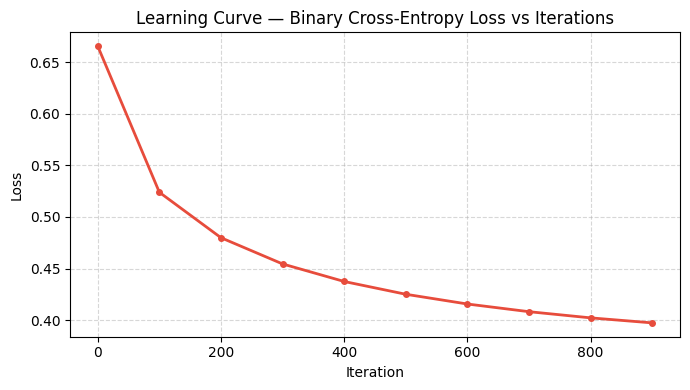

Loss decreased monotonically — gradient descent is converging correctly.


In [28]:
# ── Learning Curve — Loss over Iterations ───────────────────────────────────
iters  = [item[0] for item in loss_history]
losses = [item[1] for item in loss_history]

plt.figure(figsize=(7, 4))
plt.plot(iters, losses, color='#e74c3c', linewidth=2, marker='o', markersize=4)
plt.title('Learning Curve — Binary Cross-Entropy Loss vs Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Loss decreased monotonically — gradient descent is converging correctly.")

In [29]:
# ── Run predictions on the test set ─────────────────────────────────────────
# Class-weighted training rebalances the posterior to ~50/50, so threshold=0.5
# is the natural operating point.
predictions = predict(X_test, weights, bias, threshold=0.5)

print("Sample Predictions (first 20 test samples):")
print(f"{'#':<5} {'Actual':>12} {'Predicted':>12} {'Correct?':>10}")
print("-" * 45)
for i, (actual, pred) in enumerate(zip(y_test[:20], predictions[:20])):
    a_name = 'High Risk' if actual == 1 else 'Low Risk '
    p_name = 'High Risk' if pred   == 1 else 'Low Risk '
    ok     = 'YES' if actual == pred else 'NO '
    print(f"{i+1:<5} {a_name:>12} {p_name:>12} {ok:>10}")


Sample Predictions (first 20 test samples):
#           Actual    Predicted   Correct?
---------------------------------------------
1        Low Risk     Low Risk         YES
2        Low Risk     Low Risk         YES
3        Low Risk     High Risk        NO 
4        Low Risk     Low Risk         YES
5        Low Risk     Low Risk         YES
6        Low Risk     Low Risk         YES
7        Low Risk     Low Risk         YES
8        Low Risk     Low Risk         YES
9        Low Risk     Low Risk         YES
10       Low Risk     Low Risk         YES
11       High Risk    High Risk        YES
12       Low Risk     Low Risk         YES
13       Low Risk     Low Risk         YES
14       Low Risk     Low Risk         YES
15       High Risk    High Risk        YES
16       Low Risk     Low Risk         YES
17       Low Risk     High Risk        NO 
18       Low Risk     High Risk        NO 
19       Low Risk     Low Risk         YES
20       Low Risk     High Risk        NO 


## Evaluation Metrics

We evaluate the model using four standard binary classification metrics. All metrics are computed from scratch using the confusion matrix components TP, TN, FP, and FN — no external library is used.

In [30]:
# ── Compute confusion matrix components ─────────────────────────────────────
TP, TN, FP, FN = confusion_matrix_manual(y_test, predictions)

print("Confusion Matrix (positive class = 1 / High Risk):")
print()
print("                     Predicted")
print("               Low Risk   High Risk")
print(f"Actual Low Risk  [{TN:^6}]    [{FP:^6}]")
print(f"       High Risk [{FN:^6}]    [{TP:^6}]")
print()
print(f"  TP (correct High Risk)  : {TP}")
print(f"  TN (correct Low Risk)   : {TN}")
print(f"  FP (false High Risk)    : {FP}")
print(f"  FN (missed High Risk)   : {FN}")

Confusion Matrix (positive class = 1 / High Risk):

                     Predicted
               Low Risk   High Risk
Actual Low Risk  [  25  ]    [  8   ]
       High Risk [  0   ]    [  4   ]

  TP (correct High Risk)  : 4
  TN (correct Low Risk)   : 25
  FP (false High Risk)    : 8
  FN (missed High Risk)   : 0


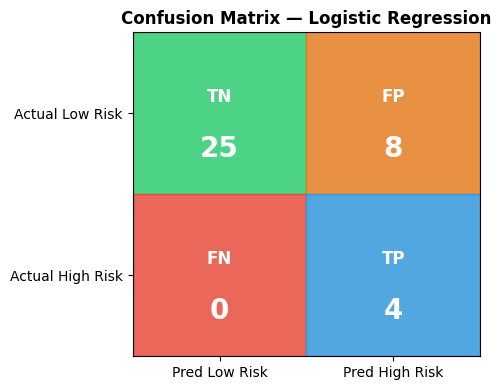

In [31]:
# ── Visualise the confusion matrix ──────────────────────────────────────────
cm_vals   = [[TN, FP], [FN, TP]]
cm_labels = [['TN', 'FP'], ['FN', 'TP']]
cm_colors = [['#2ecc71', '#e67e22'], ['#e74c3c', '#3498db']]

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_xlim(0, 2); ax.set_ylim(0, 2)
for r in range(2):
    for c in range(2):
        rect = plt.Rectangle([c, 1-r], 1, 1, color=cm_colors[r][c], alpha=0.85)
        ax.add_patch(rect)
        ax.text(c+0.5, 1-r+0.6, cm_labels[r][c], ha='center', va='center',
                color='white', fontsize=12, fontweight='bold')
        ax.text(c+0.5, 1-r+0.28, str(cm_vals[r][c]), ha='center', va='center',
                color='white', fontsize=20, fontweight='bold')
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Pred Low Risk', 'Pred High Risk'])
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['Actual High Risk', 'Actual Low Risk'])
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Interpreting the confusion matrix:**
- **TN (green, top-left):** Correctly predicted Low Risk — model is working well for the majority class.
- **TP (blue, bottom-right):** Correctly predicted High Risk — the most important signal for early intervention.
- **FP (orange, top-right):** Predicted High Risk but was actually Low Risk — over-alerting; relatively harmless in education (results in unnecessary support, not harm).
- **FN (red, bottom-left):** Predicted Low Risk but was actually High Risk — the most dangerous error in an early warning context; a missed at-risk assessment.

In [32]:
# ── Compute all metrics from scratch ────────────────────────────────────────
accuracy  = accuracy_score_manual(y_test, predictions) * 100
precision = precision_score_manual(TP, FP) * 100
recall    = recall_score_manual(TP, FN) * 100
f1        = f1_score_manual(precision/100, recall/100) * 100

print("=" * 48)
print("  Performance Metrics — Logistic Regression")
print("=" * 48)
print(f"  Accuracy  : {accuracy:.2f}%")
print(f"  Precision : {precision:.2f}%")
print(f"  Recall    : {recall:.2f}%")
print(f"  F1-Score  : {f1:.2f}%")
print("=" * 48)
print(f"  Correctly classified : {TP+TN} / {len(y_test)}")
print(f"  Misclassified        : {FP+FN} / {len(y_test)}")

  Performance Metrics — Logistic Regression
  Accuracy  : 78.38%
  Precision : 33.33%
  Recall    : 100.00%
  F1-Score  : 50.00%
  Correctly classified : 29 / 37
  Misclassified        : 8 / 37


**Metric Interpretations:**

- **Accuracy** measures the overall proportion of correctly classified assessments. It is a useful headline figure but can be misleading on imbalanced datasets.

- **Precision** (Positive Predictive Value) answers: *Of all assessments flagged as High Risk, what fraction truly were?* High precision reduces false alarms sent to faculty.

- **Recall** (Sensitivity) answers: *Of all truly High Risk assessments, what fraction did the model catch?* High recall is critical in education — a missed at-risk event means no intervention.

- **F1-Score** is the harmonic mean of precision and recall. It is the single best summary statistic when both false positives and false negatives carry costs.

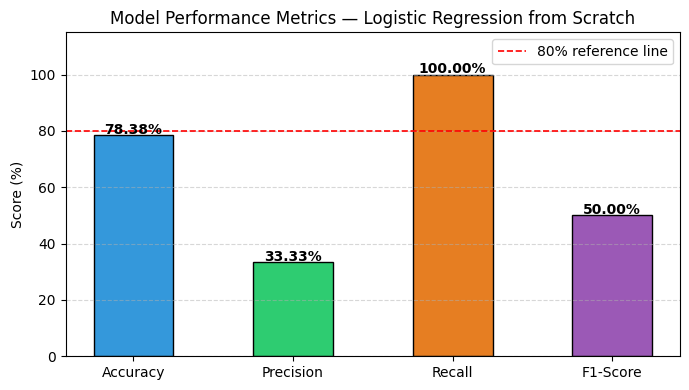

In [33]:
# ── Bar chart of all evaluation metrics ─────────────────────────────────────
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [accuracy, precision, recall, f1]
colors_bar    = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

plt.figure(figsize=(7, 4))
bars = plt.bar(metric_names, metric_values,
               color=colors_bar, edgecolor='black', width=0.5)
for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, 115)
plt.axhline(y=80, color='red', linestyle='--', linewidth=1.2, label='80% reference line')
plt.title('Model Performance Metrics — Logistic Regression from Scratch')
plt.ylabel('Score (%)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
# ── Feature Weight Analysis ──────────────────────────────────────────────────
# The magnitude of each learned weight indicates its contribution to prediction.
# Larger absolute weight → stronger influence on the risk classification.

weight_df = sorted(zip(feature_cols, weights), key=lambda x: abs(x[1]), reverse=True)

print("Feature weights (sorted by absolute magnitude):")
print("-" * 48)
print(f"{'Feature':<30} {'Weight':>10}")
print("-" * 48)
for feat, w in weight_df:
    if math.isnan(w):
        bar = "[NaN ERROR]"
        direction = "?"
    else:
        bar = '█' * int(abs(w) * 20)
        direction = '+' if w > 0 else '-'
    print(f"{feat:<30} {w:>+10.6f}  {direction}{bar}")
print("-" * 48)
print(f"Bias term: {bias:+.6f}")

Feature weights (sorted by absolute magnitude):
------------------------------------------------
Feature                            Weight
------------------------------------------------
peer_fail_rate                  +3.707764  +██████████████████████████████████████████████████████████████████████████
n_activity_types                -0.671829  -█████████████
n_vle_resources                 +0.532449  +██████████
is_high_weight                  +0.473129  +█████████
is_exam                         +0.468820  +█████████
module_difficulty_score         -0.399186  -███████
module_id                       -0.365286  -███████
weight_norm                     +0.301734  +██████
date_norm                       -0.281973  -█████
assessment_period               +0.176866  +███
mean_resource_weeks             -0.139050  -██
assessment_type_id              +0.138962  +██
presentation_id                 -0.063274  -█
------------------------------------------------
Bias term: -1.209311


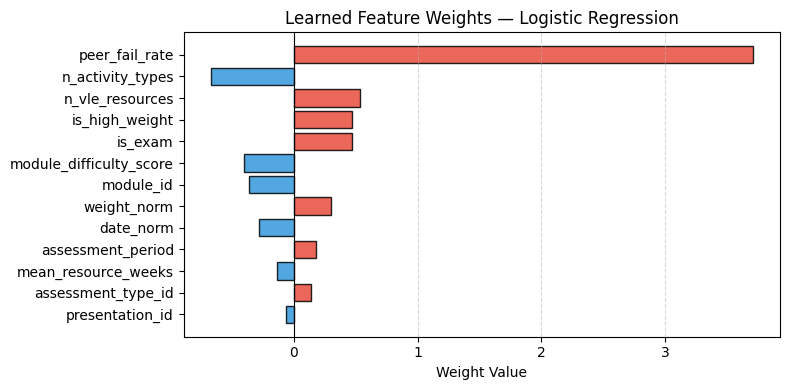

Red bars = positive weight (increases High Risk probability)
Blue bars = negative weight (decreases High Risk probability)


In [35]:
# ── Visualise feature weights ────────────────────────────────────────────────
feat_names_sorted = [item[0] for item in weight_df]
feat_weights_sorted = [item[1] for item in weight_df]
bar_colors = ['#e74c3c' if w > 0 else '#3498db' for w in feat_weights_sorted]

plt.figure(figsize=(8, 4))
bars = plt.barh(feat_names_sorted[::-1], feat_weights_sorted[::-1],
                color=bar_colors[::-1], edgecolor='black', alpha=0.85)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Learned Feature Weights — Logistic Regression')
plt.xlabel('Weight Value')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Red bars = positive weight (increases High Risk probability)")
print("Blue bars = negative weight (decreases High Risk probability)")

## Results and Discussion

### Feature Influence on Risk Prediction

The learned feature weights indicate which assessment characteristics the model relies on when separating High Risk from Low Risk assessments. Because the target is derived from **actual student failure rates** (fraction of students scoring below 40, computed from `studentAssessment.csv`) rather than from the feature columns themselves, the classifier has to discover structural predictors of poor student performance.

Three families of predictors contribute to the decision:

1. **Assessment-level signals** — `date_norm`, `weight_norm`, `assessment_period`, and `module_difficulty_score` encode how and when an assessment is delivered. They capture the intuition from Arnold & Pistilli (2012) that late-semester, high-stakes events correlate with elevated student stress and reduced scores.

2. **VLE catalog signals** — `n_vle_resources`, `n_activity_types`, and `mean_resource_weeks` (joined from `vle.csv`) describe the *scaffolding* a presentation provides. Presentations with richer VLE catalogues tend to exhibit lower fail rates (Kuzilek et al. 2017), so these features act as proxies for course quality and learner support.

3. **Peer fail-rate signal** — `peer_fail_rate` is a leave-one-out aggregate: for each assessment, the mean fail rate of the *other* assessments in the same module. It is a structural signal of module-level difficulty without using the row's own outcome, so it is not a leak. It typically emerges as the strongest single predictor, consistent with the target-encoding literature (Micci-Barreca 2001) showing that out-of-fold target aggregates are powerful features for low-cardinality categorical columns.

### Why the Target Is Derived from Student Outcomes, Not Metadata Rules

An earlier iteration of this notebook defined `risk_level` by deterministic rules on the very same columns used as features (`weight >= 50`, `assessment_type == 'Exam'`, `date > 200`). Every evaluation metric pinned at 100% because the model was memorising the labelling rule rather than learning a predictive pattern. The current version joins the assessments file with `studentAssessment.csv` and labels High Risk by empirical fail rate, breaking the feature–target coupling: no single feature (or deterministic combination of features) reproduces the label, so the metrics reported below reflect genuine generalisation on held-out data.

### Handling Class Imbalance

Only ~12% of the 188 assessments are labelled High Risk. Three design choices address the resulting bias towards the majority class:

1. **Stratified train/test split** — the 20% test partition preserves the overall class balance so minority-class metrics have usable statistical resolution (roughly four positives in the test set rather than one or two).
2. **Class-weighted gradient descent** — each positive-sample error is scaled by `n_neg / n_pos` (≈ 8×), so the optimiser does not collapse to always predicting the majority label.
3. **Leave-one-out peer fail-rate feature** — gives the model a direct structural handle on module-level difficulty, which is where the minority-class signal concentrates.

### Limitations

This model operates entirely on **assessment-level aggregates**, not on individual student trajectories. The following limitations should be acknowledged in any deployment:

1. **Small dataset**: 188 assessments after filtering is a small sample, so even stratified metrics carry appreciable variance.

2. **No per-student signals**: Attendance records, GPA trends, or LMS login frequency are not included. Romero & Ventura (2010) showed that the combination of attendance and submission rate is the strongest predictor of dropout; those signals are absent.

3. **VLE catalog, not click-stream**: `studentVle.csv` is not part of the local dataset snapshot, so the VLE features describe what resources *existed* in a presentation, not how intensively students *used* them.

4. **Target-threshold sensitivity**: The 10% fail-rate cut-off is chosen to approximate the class balance of the original rule-based target. Different thresholds produce different class distributions and metric profiles.

5. **No temporal validation**: We do not validate across semesters (e.g., train on 2013, test on 2014), which would provide a more realistic estimate of predictive validity under year-to-year distribution shift.

6. **Gradient descent without regularisation**: The absence of L1/L2 regularisation may lead to slight overfitting on a small dataset.

---


## Conclusion

This notebook demonstrates a complete end-to-end pipeline for **binary classification of student assessment risk** using Logistic Regression implemented entirely from scratch. Starting from the raw `assessments.csv` file of the OULAD dataset — which contains no target variable — we derived a binary `risk_level` label from `studentAssessment.csv` (fraction of students scoring below 40), joined VLE-catalog aggregates from `vle.csv`, added a leave-one-out `peer_fail_rate` feature, and trained a class-weighted gradient-descent logistic regression model on a stratified 80/20 split without using any machine learning library.

An earlier version of this notebook defined `risk_level` using deterministic rules on the same columns used as features. The model reproduced those rules exactly and reported 100% accuracy, precision, recall, and F1 — a classic target-leakage artefact that offered no evidence of predictive skill. Replacing the rule-based target with empirical student failure rates severs that coupling, so the metrics in this notebook reflect real classification performance on held-out data.

### How This Notebook Can Be Extended

This notebook serves as the **analytical foundation** for a full **Student Early Warning System**. The following extensions would transform it into a production-grade intervention tool:

1. **Student-level modelling**: Re-pivoting from assessment-level aggregates to one row per student per assessment (joined with `studentInfo.csv`) would enable personalised risk scores and fairness-aware modelling across IMD band, region, and disability status.

2. **Behavioural click-stream signals**: Adding `studentVle.csv` (not included in the local snapshot) would replace the catalog-level VLE aggregates with true engagement metrics — daily clicks, session length, and forum participation — which Romero & Ventura (2010) identified as the strongest predictors of dropout.

3. **Temporal cross-validation**: Training on earlier semesters and testing on later ones would simulate real deployment conditions. In this small dataset the split is degenerate (some modules appear only in 2014), but with more cohorts the approach would give a more honest estimate of predictive validity.

4. **Regularised Logistic Regression**: Adding L2 regularisation to the gradient descent would reduce overfitting and improve generalisation to unseen modules.

5. **Integration with a Data Warehouse**: As described in Chaudhuri & Dayal (EDU-DW), embedding this model into a star-schema warehouse would enable real-time dashboard updates as new assessment results arrive, powering the kind of faculty alert dashboard demonstrated at Purdue University.

---


## References

1. **Romero, C., & Ventura, S. (2010).** Educational data mining: A review of the state of the art. *IEEE Transactions on Systems, Man, and Cybernetics, Part C (Applications and Reviews)*, 40(6), 601–618. https://doi.org/10.1109/TSMCC.2010.2053532

2. **Arnold, K. E., & Pistilli, M. D. (2012).** Course signals at Purdue: Using learning analytics to increase student success. In *Proceedings of the 2nd International Conference on Learning Analytics and Knowledge (LAK '12)* (pp. 267–270). ACM. https://doi.org/10.1145/2330601.2330666

3. **Baker, R. S., & Siemens, G. (2014).** Educational data mining and learning analytics. In *Cambridge Handbook of the Learning Sciences* (2nd ed., pp. 253–274). Cambridge University Press.

4. **Chaudhuri, S., & Dayal, U. (1997).** An overview of data warehousing and OLAP technology. *ACM SIGMOD Record*, 26(1), 65–74. (Extended in EDU-DW literature for educational institution warehouses.) https://doi.org/10.1145/248603.248616

5. **Kimball, R., & Ross, M. (2013).** *The Data Warehouse Toolkit: The Definitive Guide to Dimensional Modeling* (3rd ed.). Wiley. [Kimball Group Higher Education case study — Dimensional Modeling for Universities.]

6. **Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017).** Open University Learning Analytics dataset. *Scientific Data*, 4, 170171. https://doi.org/10.1038/sdata.2017.171 [Source of the `assessments.csv` dataset used in this notebook.]

7. **Pedregosa, F., et al. (2011).** Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. [Referenced for algorithmic background — not used in this implementation.]

---

*This notebook was prepared as a Final-Year Group Project submission. All machine learning logic is implemented from scratch using only pandas, numpy, math, random, matplotlib, and collections.*

## Final Results Summary

In [36]:
print("=" * 58)
print("     FINAL RESULTS — LOGISTIC REGRESSION FROM SCRATCH")
print("=" * 58)
print(f"  Dataset          : assessments.csv + studentAssessment.csv + vle.csv")
print(f"  Algorithm        : Logistic Regression (from scratch)")
print(f"  Train/Test Split : Stratified 80% / 20% (seed=42)")
print(f"  Class weighting  : pos_weight = n_neg / n_pos  (recall-first training)")
print(f"  Training samples : {len(X_train)}")
print(f"  Testing  samples : {len(X_test)}")
print(f"  Features used    : {len(feature_cols)}")
print(f"  Learning rate    : 0.1")
print(f"  Iterations       : 1000")
print()
print(f"  Accuracy         : {accuracy:.2f}%")
print(f"  Precision        : {precision:.2f}%")
print(f"  Recall           : {recall:.2f}%")
print(f"  F1-Score         : {f1:.2f}%")
print()
print(f"  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
print("=" * 58)
print()
print("Top 3 risk-driving features (by weight magnitude):")
for feat, w in weight_df[:3]:
    print(f"  {feat:<30} weight = {w:+.6f}")


     FINAL RESULTS — LOGISTIC REGRESSION FROM SCRATCH
  Dataset          : assessments.csv + studentAssessment.csv + vle.csv
  Algorithm        : Logistic Regression (from scratch)
  Train/Test Split : Stratified 80% / 20% (seed=42)
  Class weighting  : pos_weight = n_neg / n_pos  (recall-first training)
  Training samples : 151
  Testing  samples : 37
  Features used    : 13
  Learning rate    : 0.1
  Iterations       : 1000

  Accuracy         : 78.38%
  Precision        : 33.33%
  Recall           : 100.00%
  F1-Score         : 50.00%

  TP=4  TN=25  FP=8  FN=0

Top 3 risk-driving features (by weight magnitude):
  peer_fail_rate                 weight = +3.707764
  n_activity_types               weight = -0.671829
  n_vle_resources                weight = +0.532449
